In [1]:
import os
import fastplotlib as fpl
import sys
import masknmf
import tifffile
import torch
import numpy as np

import matplotlib.pyplot as plt
import time
from typing import *
import pathlib
from pathlib import Path

import math
%load_ext line_profiler
%matplotlib inline
%load_ext autoreload

fastplotlib version from git (0.4.0) and __version__ (0.5.0) don't match.


Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),AMD Radeon RX 570 Series (RADV POLARIS10),DiscreteGPU,Vulkan,Mesa 22.3.6
✅,NVIDIA GeForce RTX 3080,DiscreteGPU,Vulkan,575.57.08
❗ limited,"llvmpipe (LLVM 15.0.6, 256 bits)",CPU,Vulkan,Mesa 22.3.6 (LLVM 15.0.6)
❌,"AMD Radeon RX 570 Series (polaris10, LLVM 15.0.6, DRM 3.49, 6.1.0-38-amd64)",Unknown,OpenGL,4.6 (Core Profile) Mesa 22.3.6


pygfx version from git (0.9.0) and __version__ (0.10.0) don't match.


In [2]:
from pprint import pprint

In [10]:
demixing_results = np.load("/home/kushal/amol_data/demixing_plane10.npz", allow_pickle = True)

In [11]:
demixing_results.keys()

KeysView(NpzFile '/home/kushal/amol_data/demixing_plane10.npz' with keys: results, metadata)

In [17]:
dm = demixing_results["results"][()]

In [13]:
pprint(demixing_results["metadata"][()])

{'background_downsampling_factor': 20,
 'data_field': 'pmd_denoise',
 'data_path': 'outputs_kushal/plane10_results.npz',
 'device': 'cuda',
 'frame_batch_size': 400,
 'out_path': 'outputs_kushal/demixing_plane10.npz',
 'ring_radius': 15,
 'spatial_hp_sigma': 4}


In [14]:
de['results'].item()

NameError: name 'de' is not defined

In [21]:
dm.residual_array

RFBOutputContext()

/home/kushal/repos/fastplotlib/fastplotlib/graphics/features/_base.py:18: UserWarning: casting float64 array to float32
  warn(f"casting {array.dtype} array to float32")


JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
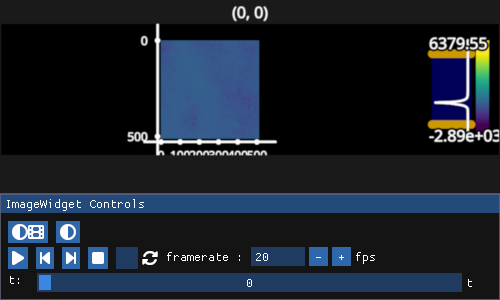

In [31]:
fpl.ImageWidget(dm.fluctuating_background_array, cmap="viridis").show()

RFBOutputContext()

/home/kushal/repos/fastplotlib/fastplotlib/graphics/features/_base.py:18: UserWarning: casting float64 array to float32
  warn(f"casting {array.dtype} array to float32")


JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
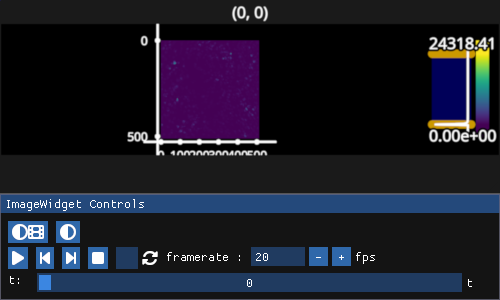

In [18]:
iw = fpl.ImageWidget(dm.ac_array, cmap="viridis")
iw.show()

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
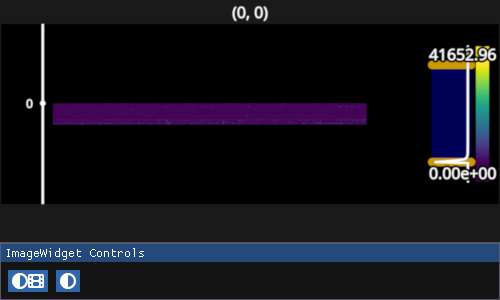

In [22]:
fpl.ImageWidget(dm.c.T.numpy(), cmap="viridis").show()

In [ ]:
iw = masknmf.visualization.make_demixing_video(demixing_results,
                                               device="cuda",
                                               v_range = [-100, 5000],
                                               show_histogram = True)
iw.show()